In [2]:
import pandas as pd
import numpy as np

In [4]:
data = pd.read_excel("MSC_ADITI_CLEANED_DATA_corrected.xlsx").sort_values('adjusted_date')
data.head()

,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status
0,2017-07-09,7.27,6.7,3,1.1,2.2,2,0,8.00,1.3,4.05,1.1,SAIL
3660,2017-07-09,0.00,6.7,0,0.0,7.8,2,0,0.00,2.2,7.05,0.0,PORT
1,2017-07-09,18.00,6.7,3,11.0,11.0,1,0,198.00,26.5,82.52,11.0,SAIL
2,2017-07-10,17.27,6.7,3,11.0,0.0,0,0,189.97,25.8,80.34,11.0,SAIL
3,2017-07-10,7.50,6.7,0,3.2,6.4,2,0,24.00,4.0,12.46,3.2,SAIL


In [6]:
data.shape

(5069, 13)

In [8]:
data.columns

Index(['adjusted_date', 'speed', 'mean_draft', 'sea_state',
       'me_actual_steaming_time', 'ae_t_steaming', 'aux_running',
       'blr_running', 'distance', 'actual_total_fo', 'total_co_2',
       'activity_time', 'status'],
      dtype='object')

# herirachial 

In [ ]:
def find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data):
    
    df = data[(data['adjusted_date'] >= start_date) & (data['adjusted_date'] <= end_date) & (data['status'] == sail_or_port_data)].sort_values('adjusted_date')
    
    # Adjust sea_state (invert the scale for clustering purposes)
    df['new_ss'] = 10 - df['sea_state']
    
    # Define the columns to use for clustering
    clusterdf = df[[  
        'speed', 
        'mean_draft',  
        'new_ss',  
        'me_actual_steaming_time',  
        'ae_t_steaming',
        'aux_running', 
        'blr_running', 
        'activity_time'
    ]].copy()

    # Normalize the data for t-SNE
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(clusterdf)
    
    
    # Apply t-SNE for dimensionality reduction
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    df_tsne = tsne.fit_transform(df_scaled)

    # Convert the t-SNE results to a DataFrame
    df_tsne = pd.DataFrame(df_tsne, columns=['TSNE1', 'TSNE2'])

    # Visualize the t-SNE output
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'])
    plt.title('t-SNE Visualization of Vessel Operational Data')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.show()

    # Perform hierarchical clustering
    from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
    linked = linkage(df_tsne, method='ward')

    # Plot the dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(linked)
    plt.title('Dendrogram for Hierarchical Clustering')
    plt.show()

    # Cut the dendrogram to form clusters
    cluster_labels = fcluster(linked, no_of_profiles, criterion='maxclust')

    # Add the cluster labels to the t-SNE DataFrame
    df_tsne['Cluster'] = cluster_labels

    # Visualize clusters on the t-SNE plot
    plt.figure(figsize=(10, 6))
    for cluster in range(1, no_of_profiles + 1):
        subset = df_tsne[df_tsne['Cluster'] == cluster]
        plt.scatter(subset['TSNE1'], subset['TSNE2'], label=f'Cluster {cluster}')
    plt.title('t-SNE Clusters of Vessel Operational Data')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.legend()
    plt.show()

    # Add cluster labels to the original DataFrame
    clusterdf['Cluster'] = df_tsne['Cluster'].values
    clusterdf['sea_state'] = 10 - clusterdf['new_ss']  # Restore the original sea_state scale
    clusterdf['sea_state'] = clusterdf['sea_state'].apply(lambda x: int(x))
    clusterdf.drop('new_ss', axis=1, inplace=True)

    # Step 1: Rebalance me_actual_steaming_time across clusters
    total_steaming_time = clusterdf['me_actual_steaming_time'].sum()  # Total steaming time across all clusters
    cluster_sizes = clusterdf['Cluster'].value_counts()  # Number of rows in each cluster
    cluster_proportions = cluster_sizes / cluster_sizes.sum()  # Proportion of rows in each cluster

    # Adjust the me_actual_steaming_time based on the cluster proportions
    clusterdf['adjusted_me_steaming_time'] = clusterdf['Cluster'].map(
        cluster_proportions * total_steaming_time
    )

    # Recalculate the cluster profile after adjusting the steaming time
    cluster_profile = clusterdf.groupby(['Cluster']).mean().reset_index().round(2)

    # Recalculate the adjusted steaming time
    adjusted_steaming_time = clusterdf.groupby('Cluster')['adjusted_me_steaming_time'].sum().reset_index().round(2)

    # Merge adjusted steaming time with cluster profile
    mergedf = pd.merge(cluster_profile, adjusted_steaming_time, on='Cluster', how='inner')
    mergedf.rename(columns={
        'adjusted_me_steaming_time': 'adjusted_me_actual_steaming_time_days'
    }, inplace=True)

    # If the data is for 'SAIL', calculate additional metrics
    if sail_or_port_data == 'SAIL':
        me_time = (clusterdf.groupby('Cluster')['me_actual_steaming_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, me_time, on='Cluster', how='inner')
        mergedf.rename(columns={
            'me_actual_steaming_time_x': 'me_actual_steaming_time_mean',
            'me_actual_steaming_time_y': 'me_actual_steaming_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for sail status
        profile_data = mergedf[['speed', 'mean_draft', 'sea_state',
                                'me_actual_steaming_time_mean', 'me_actual_steaming_time_days',
                                'ae_t_steaming', 'aux_running', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['speed', 'mean_draft', 'sea_state',
                                                                  'me_actual_steaming_time', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'Cluster']]
    else:
        # For port status, calculate activity_time
        mergedf = (clusterdf.groupby('Cluster')['activity_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, mergedf, on='Cluster', how='inner')
        mergedf.rename(columns={
            'activity_time_x': 'activity_time_mean',
            'activity_time_y': 'activity_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for port status
        profile_data = mergedf[['mean_draft', 'ae_t_steaming', 'aux_running',
                                'activity_time_mean', 'activity_time_days', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['mean_draft', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'activity_time', 'Cluster']]

    return cluster_data, profile_data, df_tsne


In [ ]:
start_date = '2017-07-09'
end_date = '2024-12-31'
no_of_profiles = 3

# For SAIL data
sail_or_port_data = 'SAIL'
cluster_data_hr, profile_data_hr, df_tsne = find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data)


In [ ]:
profile_data_hr

# kmeans

In [ ]:
def find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data):
    
    df = data[(data['adjusted_date'] >= start_date) & (data['adjusted_date'] <= end_date) & (data['status'] == sail_or_port_data)].sort_values('adjusted_date')
    
    # Adjust sea_state (invert the scale for clustering purposes)
    df['new_ss'] = 10 - df['sea_state']
    
    # Define the columns to use for clustering
    clusterdf = df[[  
        'speed', 
        'mean_draft',  
        'new_ss',  
        'me_actual_steaming_time',  
        'ae_t_steaming',
        'aux_running', 
        'blr_running', 
        'activity_time'
    ]].copy()

    # Normalize the data for t-SNE
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(clusterdf)
    
    # Apply t-SNE for dimensionality reduction
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    df_tsne = tsne.fit_transform(df_scaled)

    # Convert the t-SNE results to a DataFrame
    df_tsne = pd.DataFrame(df_tsne, columns=['TSNE1', 'TSNE2'])

    # Visualize the t-SNE output
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'])
    plt.title('t-SNE Visualization of Vessel Operational Data')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.show()

    # Perform KMeans clustering
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=no_of_profiles, random_state=42)
    cluster_labels = kmeans.fit_predict(df_tsne)

    # Add the cluster labels to the t-SNE DataFrame
    df_tsne['Cluster'] = cluster_labels

    # Visualize clusters on the t-SNE plot
    plt.figure(figsize=(10, 6))
    for cluster in range(no_of_profiles):
        subset = df_tsne[df_tsne['Cluster'] == cluster]
        plt.scatter(subset['TSNE1'], subset['TSNE2'], label=f'Cluster {cluster + 1}')
    plt.title('t-SNE Clusters of Vessel Operational Data (KMeans)')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.legend()
    plt.show()

    # Add cluster labels to the original DataFrame
    clusterdf['Cluster'] = df_tsne['Cluster'].values
    clusterdf['sea_state'] = 10 - clusterdf['new_ss']  # Restore the original sea_state scale
    clusterdf['sea_state'] = clusterdf['sea_state'].apply(lambda x: int(x))
    clusterdf.drop('new_ss', axis=1, inplace=True)

    # Step 1: Rebalance me_actual_steaming_time across clusters
    total_steaming_time = clusterdf['me_actual_steaming_time'].sum()  # Total steaming time across all clusters
    cluster_sizes = clusterdf['Cluster'].value_counts()  # Number of rows in each cluster
    cluster_proportions = cluster_sizes / cluster_sizes.sum()  # Proportion of rows in each cluster

    # Adjust the me_actual_steaming_time based on the cluster proportions
    clusterdf['adjusted_me_steaming_time'] = clusterdf['Cluster'].map(
        cluster_proportions * total_steaming_time
    )

    # Recalculate the cluster profile after adjusting the steaming time
    cluster_profile = clusterdf.groupby(['Cluster']).mean().reset_index().round(2)

    # Recalculate the adjusted steaming time
    adjusted_steaming_time = clusterdf.groupby('Cluster')['adjusted_me_steaming_time'].sum().reset_index().round(2)

    # Merge adjusted steaming time with cluster profile
    mergedf = pd.merge(cluster_profile, adjusted_steaming_time, on='Cluster', how='inner')
    mergedf.rename(columns={
        'adjusted_me_steaming_time': 'adjusted_me_actual_steaming_time_days'
    }, inplace=True)

    # If the data is for 'SAIL', calculate additional metrics
    if sail_or_port_data == 'SAIL':
        me_time = (clusterdf.groupby('Cluster')['me_actual_steaming_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, me_time, on='Cluster', how='inner')
        mergedf.rename(columns={
            'me_actual_steaming_time_x': 'me_actual_steaming_time_mean',
            'me_actual_steaming_time_y': 'me_actual_steaming_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for sail status
        profile_data = mergedf[['speed', 'mean_draft', 'sea_state',
                                'me_actual_steaming_time_mean', 'me_actual_steaming_time_days',
                                'ae_t_steaming', 'aux_running', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['speed', 'mean_draft', 'sea_state',
                                                                  'me_actual_steaming_time', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'Cluster']]
    else:
        # For port status, calculate activity_time
        mergedf = (clusterdf.groupby('Cluster')['activity_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, mergedf, on='Cluster', how='inner')
        mergedf.rename(columns={
            'activity_time_x': 'activity_time_mean',
            'activity_time_y': 'activity_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for port status
        profile_data = mergedf[['mean_draft', 'ae_t_steaming', 'aux_running',
                                'activity_time_mean', 'activity_time_days', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['mean_draft', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'activity_time', 'Cluster']]

    return cluster_data, profile_data, df_tsne


In [ ]:
start_date = '2017-07-09'
end_date = '2024-12-31'
no_of_profiles = 3

# For SAIL data
sail_or_port_data = 'SAIL'
cluster_data_km, profile_data_km, df_tsne = find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data)


In [ ]:
profile_data_km

# dbscan

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

def find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data):
    df = data[(data['adjusted_date'] >= start_date) & (data['adjusted_date'] <= end_date) & (data['status'] == sail_or_port_data)].sort_values('adjusted_date')
    
    # Adjust sea_state (invert the scale for clustering purposes)
    df['new_ss'] = 10 - df['sea_state']
    
    # Define the columns to use for clustering
    clusterdf = df[[  
        'speed', 
        'mean_draft',  
        'new_ss',  
        'me_actual_steaming_time',  
        'ae_t_steaming',
        'aux_running', 
        'blr_running', 
        'activity_time'
    ]].copy()

    # Normalize the data for clustering
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(clusterdf)
    
    # Apply t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    df_tsne = tsne.fit_transform(df_scaled)

    # Convert the t-SNE results to a DataFrame
    df_tsne = pd.DataFrame(df_tsne, columns=['TSNE1', 'TSNE2'])

    # Visualize the t-SNE output
    plt.figure(figsize=(10, 6))
    plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'])
    plt.title('t-SNE Visualization of Vessel Operational Data')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.show()

    # Perform DBSCAN clustering
    dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust the eps and min_samples as needed
    cluster_labels = dbscan.fit_predict(df_tsne)

    # If DBSCAN produces more or less than 3 clusters, adjust it to have exactly 3 clusters
    unique_labels = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)  # Exclude noise (-1)
    
    # Force the number of clusters to 3 if DBSCAN results differ
    if unique_labels != no_of_profiles:
        # Assign each point to one of the 3 clusters
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=no_of_profiles, random_state=42)
        cluster_labels = kmeans.fit_predict(df_tsne)

    # Add the cluster labels to the t-SNE DataFrame
    df_tsne['Cluster'] = cluster_labels

    # Visualize clusters on the t-SNE plot
    plt.figure(figsize=(10, 6))
    for cluster in range(no_of_profiles):
        subset = df_tsne[df_tsne['Cluster'] == cluster]
        plt.scatter(subset['TSNE1'], subset['TSNE2'], label=f'Cluster {cluster + 1}')
    plt.title('t-SNE Clusters of Vessel Operational Data (DBSCAN)')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.legend()
    plt.show()

    # Add cluster labels to the original DataFrame
    clusterdf['Cluster'] = df_tsne['Cluster'].values
    clusterdf['sea_state'] = 10 - clusterdf['new_ss']  # Restore the original sea_state scale
    clusterdf['sea_state'] = clusterdf['sea_state'].apply(lambda x: int(x))
    clusterdf.drop('new_ss', axis=1, inplace=True)

    # Step 1: Rebalance me_actual_steaming_time across clusters
    total_steaming_time = clusterdf['me_actual_steaming_time'].sum()  # Total steaming time across all clusters
    cluster_sizes = clusterdf['Cluster'].value_counts()  # Number of rows in each cluster
    cluster_proportions = cluster_sizes / cluster_sizes.sum()  # Proportion of rows in each cluster

    # Adjust the me_actual_steaming_time based on the cluster proportions
    clusterdf['adjusted_me_steaming_time'] = clusterdf['Cluster'].map(
        cluster_proportions * total_steaming_time
    )

    # Recalculate the cluster profile after adjusting the steaming time
    cluster_profile = clusterdf.groupby(['Cluster']).mean().reset_index().round(2)

    # Recalculate the adjusted steaming time
    adjusted_steaming_time = clusterdf.groupby('Cluster')['adjusted_me_steaming_time'].sum().reset_index().round(2)

    # Merge adjusted steaming time with cluster profile
    mergedf = pd.merge(cluster_profile, adjusted_steaming_time, on='Cluster', how='inner')
    mergedf.rename(columns={
        'adjusted_me_steaming_time': 'adjusted_me_actual_steaming_time_days'
    }, inplace=True)

    # If the data is for 'SAIL', calculate additional metrics
    if sail_or_port_data == 'SAIL':
        me_time = (clusterdf.groupby('Cluster')['me_actual_steaming_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, me_time, on='Cluster', how='inner')
        mergedf.rename(columns={
            'me_actual_steaming_time_x': 'me_actual_steaming_time_mean',
            'me_actual_steaming_time_y': 'me_actual_steaming_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for sail status
        profile_data = mergedf[['speed', 'mean_draft', 'sea_state',
                                'me_actual_steaming_time_mean', 'me_actual_steaming_time_days',
                                'ae_t_steaming', 'aux_running', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['speed', 'mean_draft', 'sea_state',
                                                                  'me_actual_steaming_time', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'Cluster']]
    else:
        # For port status, calculate activity_time
        mergedf = (clusterdf.groupby('Cluster')['activity_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, mergedf, on='Cluster', how='inner')
        mergedf.rename(columns={
            'activity_time_x': 'activity_time_mean',
            'activity_time_y': 'activity_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for port status
        profile_data = mergedf[['mean_draft', 'ae_t_steaming', 'aux_running',
                                'activity_time_mean', 'activity_time_days', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['mean_draft', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'activity_time', 'Cluster']]

    return cluster_data, profile_data, df_tsne


In [ ]:
start_date = '2017-07-09'
end_date = '2024-12-31'
no_of_profiles = 3

# For SAIL data
sail_or_port_data = 'SAIL'
cluster_data_db, profile_data_db, df_tsne = find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data)


In [ ]:
profile_data_db

# agglormative

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

def find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data):
    # Filter the data based on the date range and status (sail/port)
    df = data[(data['adjusted_date'] >= start_date) & (data['adjusted_date'] <= end_date) & (data['status'] == sail_or_port_data)].sort_values('adjusted_date')
    
    # Adjust sea_state (invert the scale for clustering purposes)
    df['new_ss'] = 10 - df['sea_state']
    
    # Define the columns to use for clustering
    clusterdf = df[[  
        'speed', 
        'mean_draft',  
        'new_ss',  
        'me_actual_steaming_time',  
        'ae_t_steaming',
        'aux_running', 
        'blr_running', 
        'activity_time'
    ]].copy()

    # Normalize the data for clustering
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(clusterdf)
    
    # Apply t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    df_tsne = tsne.fit_transform(df_scaled)

    # Convert the t-SNE results to a DataFrame
    df_tsne = pd.DataFrame(df_tsne, columns=['TSNE1', 'TSNE2'])

    # Visualize the t-SNE output
    plt.figure(figsize=(10, 6))
    plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'])
    plt.title('t-SNE Visualization of Vessel Operational Data')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.show()

    # Perform Agglomerative Clustering with the correct metric parameter
    agg_clustering = AgglomerativeClustering(n_clusters=no_of_profiles, linkage='ward', metric='euclidean')
    cluster_labels = agg_clustering.fit_predict(df_tsne)

    # Add the cluster labels to the t-SNE DataFrame
    df_tsne['Cluster'] = cluster_labels

    # Visualize clusters on the t-SNE plot
    plt.figure(figsize=(10, 6))
    for cluster in range(no_of_profiles):
        subset = df_tsne[df_tsne['Cluster'] == cluster]
        plt.scatter(subset['TSNE1'], subset['TSNE2'], label=f'Cluster {cluster + 1}')
    plt.title('t-SNE Clusters of Vessel Operational Data (Agglomerative Clustering)')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.legend()
    plt.show()

    # Add cluster labels to the original DataFrame
    clusterdf['Cluster'] = df_tsne['Cluster'].values
    clusterdf['sea_state'] = 10 - clusterdf['new_ss']  # Restore the original sea_state scale
    clusterdf['sea_state'] = clusterdf['sea_state'].apply(lambda x: int(x))
    clusterdf.drop('new_ss', axis=1, inplace=True)

    # Step 1: Rebalance me_actual_steaming_time across clusters
    total_steaming_time = clusterdf['me_actual_steaming_time'].sum()  # Total steaming time across all clusters
    cluster_sizes = clusterdf['Cluster'].value_counts()  # Number of rows in each cluster
    cluster_proportions = cluster_sizes / cluster_sizes.sum()  # Proportion of rows in each cluster

    # Adjust the me_actual_steaming_time based on the cluster proportions
    clusterdf['adjusted_me_steaming_time'] = clusterdf['Cluster'].map(
        cluster_proportions * total_steaming_time
    )

    # Recalculate the cluster profile after adjusting the steaming time
    cluster_profile = clusterdf.groupby(['Cluster']).mean().reset_index().round(2)

    # Recalculate the adjusted steaming time
    adjusted_steaming_time = clusterdf.groupby('Cluster')['adjusted_me_steaming_time'].sum().reset_index().round(2)

    # Merge adjusted steaming time with cluster profile
    mergedf = pd.merge(cluster_profile, adjusted_steaming_time, on='Cluster', how='inner')
    mergedf.rename(columns={
        'adjusted_me_steaming_time': 'adjusted_me_actual_steaming_time_days'
    }, inplace=True)

    # If the data is for 'SAIL', calculate additional metrics
    if sail_or_port_data == 'SAIL':
        me_time = (clusterdf.groupby('Cluster')['me_actual_steaming_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, me_time, on='Cluster', how='inner')
        mergedf.rename(columns={
            'me_actual_steaming_time_x': 'me_actual_steaming_time_mean',
            'me_actual_steaming_time_y': 'me_actual_steaming_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for sail status
        profile_data = mergedf[['speed', 'mean_draft', 'sea_state',
                                'me_actual_steaming_time_mean', 'me_actual_steaming_time_days',
                                'ae_t_steaming', 'aux_running', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['speed', 'mean_draft', 'sea_state',
                                                                  'me_actual_steaming_time', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'Cluster']]
    else:
        # For port status, calculate activity_time
        mergedf = (clusterdf.groupby('Cluster')['activity_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, mergedf, on='Cluster', how='inner')
        mergedf.rename(columns={
            'activity_time_x': 'activity_time_mean',
            'activity_time_y': 'activity_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for port status
        profile_data = mergedf[['mean_draft', 'ae_t_steaming', 'aux_running',
                                'activity_time_mean', 'activity_time_days', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['mean_draft', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'activity_time', 'Cluster']]

    return cluster_data, profile_data, df_tsne


In [ ]:
start_date = '2017-07-09'
end_date = '2024-12-31'
no_of_profiles = 3

# For SAIL data
sail_or_port_data = 'SAIL'
cluster_data, profile_data, tsne_data = find_data_clusters_and_profile(
    start_date=start_date,
    end_date=end_date,
    sail_or_port_data=sail_or_port_data,
    no_of_profiles=no_of_profiles,
    data=data
)


In [ ]:
profile_data

#### balance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data):
    # Filter data based on the date range and status (SAIL/PORT)
    df = data[(data['adjusted_date'] >= start_date) & (data['adjusted_date'] <= end_date) & (data['status'] == sail_or_port_data)].sort_values('adjusted_date')
    
    # Adjust sea_state (invert the scale for clustering purposes)
    df['new_ss'] = 10 - df['sea_state']
    
    # Define the columns to use for clustering
    clusterdf = df[[  
        'speed', 
        'mean_draft',  
        'new_ss',  
        'me_actual_steaming_time',  
        'ae_t_steaming',
        'aux_running', 
        'blr_running', 
        'activity_time'
    ]].copy()

    # Normalize the data for t-SNE
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(clusterdf)
    
    # Apply t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    df_tsne = tsne.fit_transform(df_scaled)

    # Convert the t-SNE results to a DataFrame
    df_tsne = pd.DataFrame(df_tsne, columns=['TSNE1', 'TSNE2'])

    # Visualize the t-SNE output
    plt.figure(figsize=(10, 6))
    plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'])
    plt.title('t-SNE Visualization of Vessel Operational Data')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.show()

    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=no_of_profiles, random_state=42)
    cluster_labels = kmeans.fit_predict(df_tsne)

    # Add the cluster labels to the t-SNE DataFrame
    df_tsne['Cluster'] = cluster_labels

    # Visualize clusters on the t-SNE plot
    plt.figure(figsize=(10, 6))
    for cluster in range(no_of_profiles):
        subset = df_tsne[df_tsne['Cluster'] == cluster]
        plt.scatter(subset['TSNE1'], subset['TSNE2'], label=f'Cluster {cluster + 1}')
    plt.title('t-SNE Clusters of Vessel Operational Data (KMeans)')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.legend()
    plt.show()

    # Add cluster labels to the original DataFrame
    clusterdf['Cluster'] = df_tsne['Cluster'].values
    clusterdf['sea_state'] = 10 - clusterdf['new_ss']  # Restore the original sea_state scale
    clusterdf['sea_state'] = clusterdf['sea_state'].apply(lambda x: int(x))
    clusterdf.drop('new_ss', axis=1, inplace=True)

    # Step 1: Rebalance me_actual_steaming_time across clusters
    total_steaming_time = clusterdf['me_actual_steaming_time'].sum()  # Total steaming time across all clusters
    cluster_sizes = clusterdf['Cluster'].value_counts()  # Number of rows in each cluster
    cluster_proportions = cluster_sizes / cluster_sizes.sum()  # Proportion of rows in each cluster

    # Adjust the me_actual_steaming_time based on the cluster proportions
    clusterdf['adjusted_me_steaming_time'] = clusterdf['Cluster'].map(
        cluster_proportions * total_steaming_time
    )

    # Recalculate the cluster profile after adjusting the steaming time
    cluster_profile = clusterdf.groupby(['Cluster']).mean().reset_index().round(2)

    # Recalculate the adjusted steaming time
    adjusted_steaming_time = clusterdf.groupby('Cluster')['adjusted_me_steaming_time'].sum().reset_index().round(2)

    # Merge adjusted steaming time with cluster profile
    mergedf = pd.merge(cluster_profile, adjusted_steaming_time, on='Cluster', how='inner')
    mergedf.rename(columns={
        'adjusted_me_steaming_time': 'adjusted_me_actual_steaming_time_days'
    }, inplace=True)

    # If the data is for 'SAIL', calculate additional metrics
    if sail_or_port_data == 'SAIL':
        me_time = (clusterdf.groupby('Cluster')['me_actual_steaming_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, me_time, on='Cluster', how='inner')
        mergedf.rename(columns={
            'me_actual_steaming_time_x': 'me_actual_steaming_time_mean',
            'me_actual_steaming_time_y': 'me_actual_steaming_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for sail status
        profile_data = mergedf[['speed', 'mean_draft', 'sea_state',
                                'me_actual_steaming_time_mean', 'me_actual_steaming_time_days',
                                'ae_t_steaming', 'aux_running', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['speed', 'mean_draft', 'sea_state',
                                                                  'me_actual_steaming_time', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'Cluster']]
    else:
        # For port status, calculate activity_time
        mergedf = (clusterdf.groupby('Cluster')['activity_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, mergedf, on='Cluster', how='inner')
        mergedf.rename(columns={
            'activity_time_x': 'activity_time_mean',
            'activity_time_y': 'activity_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for port status
        profile_data = mergedf[['mean_draft', 'ae_t_steaming', 'aux_running',
                                'activity_time_mean', 'activity_time_days', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['mean_draft', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'activity_time', 'Cluster']]

    return cluster_data, profile_data, df_tsne



In [ ]:
start_date = '2017-07-09'
end_date = '2024-12-31'
no_of_profiles = 3

# For SAIL data
sail_or_port_data = 'SAIL'
cluster_data_bal, profile_data_bal, df_tsne = find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data)


In [ ]:
profile_data_bal

# without tsne

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

def find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data):
    # Filter the data based on the date range and status (sail/port)
    df = data[(data['adjusted_date'] >= start_date) & (data['adjusted_date'] <= end_date) & (data['status'] == sail_or_port_data)].sort_values('adjusted_date')
    
    # Adjust sea_state (invert the scale for clustering purposes)
    df['new_ss'] = 10 - df['sea_state']
    
    # Define the columns to use for clustering
    clusterdf = df[[  
        'speed', 
        'mean_draft',  
        'new_ss',  
        'me_actual_steaming_time',  
        'ae_t_steaming',
        'aux_running', 
        'blr_running', 
        'activity_time'
    ]].copy()

    # Normalize the data for clustering
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(clusterdf)

    # Perform hierarchical clustering directly on the high-dimensional data
    linked = linkage(df_scaled, method='ward')  # You can change 'ward' to 'complete', 'average', etc.

    # Plot the dendrogram to visualize the hierarchical clustering process
    plt.figure(figsize=(10, 7))
    dendrogram(linked)
    plt.title('Dendrogram for Hierarchical Clustering')
    plt.show()

    # Cut the dendrogram to form clusters
    cluster_labels = fcluster(linked, no_of_profiles, criterion='maxclust')

    # Add the cluster labels to the original DataFrame
    clusterdf['Cluster'] = cluster_labels
    clusterdf['sea_state'] = 10 - clusterdf['new_ss']  # Restore the original sea_state scale
    clusterdf['sea_state'] = clusterdf['sea_state'].apply(lambda x: int(x))
    clusterdf.drop('new_ss', axis=1, inplace=True)

    # Step 1: Rebalance me_actual_steaming_time across clusters
    total_steaming_time = clusterdf['me_actual_steaming_time'].sum()  # Total steaming time across all clusters
    cluster_sizes = clusterdf['Cluster'].value_counts()  # Number of rows in each cluster
    cluster_proportions = cluster_sizes / cluster_sizes.sum()  # Proportion of rows in each cluster

    # Adjust the me_actual_steaming_time based on the cluster proportions
    clusterdf['adjusted_me_steaming_time'] = clusterdf['Cluster'].map(
        cluster_proportions * total_steaming_time
    )

    # Recalculate the cluster profile after adjusting the steaming time
    cluster_profile = clusterdf.groupby(['Cluster']).mean().reset_index().round(2)

    # Recalculate the adjusted steaming time
    adjusted_steaming_time = clusterdf.groupby('Cluster')['adjusted_me_steaming_time'].sum().reset_index().round(2)

    # Merge adjusted steaming time with cluster profile
    mergedf = pd.merge(cluster_profile, adjusted_steaming_time, on='Cluster', how='inner')
    mergedf.rename(columns={
        'adjusted_me_steaming_time': 'adjusted_me_actual_steaming_time_days'
    }, inplace=True)

    # If the data is for 'SAIL', calculate additional metrics
    if sail_or_port_data == 'SAIL':
        me_time = (clusterdf.groupby('Cluster')['me_actual_steaming_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, me_time, on='Cluster', how='inner')
        mergedf.rename(columns={
            'me_actual_steaming_time_x': 'me_actual_steaming_time_mean',
            'me_actual_steaming_time_y': 'me_actual_steaming_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for sail status
        profile_data = mergedf[['speed', 'mean_draft', 'sea_state',
                                'me_actual_steaming_time_mean', 'me_actual_steaming_time_days',
                                'ae_t_steaming', 'aux_running', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['speed', 'mean_draft', 'sea_state',
                                                                  'me_actual_steaming_time', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'Cluster']]
    else:
        # For port status, calculate activity_time
        mergedf = (clusterdf.groupby('Cluster')['activity_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, mergedf, on='Cluster', how='inner')
        mergedf.rename(columns={
            'activity_time_x': 'activity_time_mean',
            'activity_time_y': 'activity_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))

        # Prepare profile and cluster data for port status
        profile_data = mergedf[['mean_draft', 'ae_t_steaming', 'aux_running',
                                'activity_time_mean', 'activity_time_days', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['mean_draft', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'activity_time', 'Cluster']]

    return cluster_data, profile_data



In [ ]:
start_date = '2017-07-09'
end_date = '2024-12-31'
no_of_profiles = 3

# For SAIL data
sail_or_port_data = 'SAIL'
cluster_data_nt, profile_data_nt = find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data)


In [ ]:
profile_data_nt

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

def find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data):
    # Filter the data based on the date range and status (sail/port)
    df = data[(data['adjusted_date'] >= start_date) & (data['adjusted_date'] <= end_date) & (data['status'] == sail_or_port_data)].sort_values('adjusted_date')
    
    # Define the columns to use for clustering
    clusterdf = df[[  
        'speed', 
        'mean_draft',  
        'sea_state',  
        'me_actual_steaming_time',  
        'ae_t_steaming',
        'aux_running', 
        'blr_running', 
        'activity_time'
    ]].copy()

    # Normalize the data for clustering
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(clusterdf)
    
    # Perform K-Means Clustering
    kmeans = KMeans(n_clusters=no_of_profiles, random_state=42)
    cluster_labels = kmeans.fit_predict(df_scaled)

    # Add the cluster labels to the original DataFrame
    clusterdf['Cluster'] = cluster_labels

    # Visualize the clusters
    plt.figure(figsize=(10, 6))
    plt.scatter(clusterdf['speed'], clusterdf['mean_draft'], c=cluster_labels, cmap='viridis', marker='o')
    plt.title('K-Means Clusters of Vessel Operational Data')
    plt.xlabel('Speed')
    plt.ylabel('Mean Draft')
    plt.colorbar(label='Cluster')
    plt.show()

    # Recalculate the cluster profile
    cluster_profile = clusterdf.groupby(['Cluster']).mean().reset_index().round(2)

    # If the data is for 'SAIL', calculate additional metrics
    if sail_or_port_data == 'SAIL':
        me_time = (clusterdf.groupby('Cluster')['me_actual_steaming_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, me_time, on='Cluster', how='inner')
        mergedf.rename(columns={
            'me_actual_steaming_time_x': 'me_actual_steaming_time_mean',
            'me_actual_steaming_time_y': 'me_actual_steaming_time_days'
        }, inplace=True)
        # Prepare profile and cluster data for sail status
        profile_data = mergedf[['speed', 'mean_draft', 'sea_state',
                                'me_actual_steaming_time_mean', 'me_actual_steaming_time_days',
                                'ae_t_steaming', 'aux_running', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['speed', 'mean_draft', 'sea_state',
                                                                  'me_actual_steaming_time', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'Cluster']]
    else:
        # For port status, calculate activity_time
        mergedf = (clusterdf.groupby('Cluster')['activity_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, mergedf, on='Cluster', how='inner')
        mergedf.rename(columns={
            'activity_time_x': 'activity_time_mean',
            'activity_time_y': 'activity_time_days'
        }, inplace=True)
        # Prepare profile and cluster data for port status
        profile_data = mergedf[['mean_draft', 'ae_t_steaming', 'aux_running',
                                'activity_time_mean', 'activity_time_days', 'blr_running', 'Cluster']]
        
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['mean_draft', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'activity_time', 'Cluster']]

    return cluster_data, profile_data



In [ ]:
start_date = '2017-07-09'
end_date = '2024-12-31'
no_of_profiles = 3

# For SAIL data
sail_or_port_data = 'SAIL'
cluster_data_ntk, profile_data_ntk = find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data)


In [ ]:
profile_data_ntk

# pca final code

In [1]:
def find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data):
    df = data[(data['adjusted_date'] >= start_date) & (data['adjusted_date'] <= end_date) & (data['status'] == sail_or_port_data)].sort_values('adjusted_date')
    df['new_ss'] = 10 - df['sea_state']
    # Define the columns to use for clustering
    clusterdf = df[['speed', 'mean_draft', 'new_ss', 'me_actual_steaming_time',  
                    'ae_t_steaming', 'aux_running', 'blr_running', 'activity_time']].copy()

        # Check for columns with NaN values in the DataFrame

    # Store adjusted_date separately for later use
    adjusted_date = df['adjusted_date']
    # Normalize the data for PCA
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
 
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(clusterdf)
 
    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_scaled)
 
    # Convert the PCA results to a DataFrame
    df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
 
    # Visualize the PCA output
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.scatter(df_pca['PCA1'], df_pca['PCA2'])
    plt.title('PCA Visualization of Vessel Operational Data')
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.show()
 
    # Perform hierarchical clustering
    from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
    linked = linkage(df_pca, method='ward')
 
    # Plot the dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(linked)
    plt.title('Dendrogram for Hierarchical Clustering')
    plt.show()
 
    # Cut the dendrogram to form clusters
    cluster_labels = fcluster(linked, no_of_profiles, criterion='maxclust')
 
    # Add the cluster labels to the PCA DataFrame
    df_pca['Cluster'] = cluster_labels
 
    # Visualize clusters on the PCA plot
    plt.figure(figsize=(10, 6))
    for cluster in range(1, no_of_profiles + 1):
        subset = df_pca[df_pca['Cluster'] == cluster]
        plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {cluster}')
    plt.title('PCA Clusters of Vessel Operational Data')
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.legend()
    plt.show()
 
    # Add cluster labels to the original DataFrame
    clusterdf['Cluster'] = df_pca['Cluster'].values
    clusterdf['adjusted_date'] = adjusted_date
    clusterdf['sea_state'] = 10 - clusterdf['new_ss']  # Restore the original sea_state scale
    clusterdf['sea_state'] = clusterdf['sea_state'].apply(lambda x: int(x))
    clusterdf.drop('new_ss', axis=1, inplace=True)
 
    # Step 1: Rebalance me_actual_steaming_time across clusters
    total_steaming_time = clusterdf['me_actual_steaming_time'].sum()  # Total steaming time across all clusters
    cluster_sizes = clusterdf['Cluster'].value_counts()  # Number of rows in each cluster
    cluster_proportions = cluster_sizes / cluster_sizes.sum()  # Proportion of rows in each cluster
 
    # Adjust the me_actual_steaming_time based on the cluster proportions
    clusterdf['adjusted_me_steaming_time'] = clusterdf['Cluster'].map(
        cluster_proportions * total_steaming_time
    )
 
    # Recalculate the cluster profile after adjusting the steaming time
    cluster_profile = clusterdf.groupby(['Cluster']).mean().reset_index().round(2)
 
    # Recalculate the adjusted steaming time
    adjusted_steaming_time = clusterdf.groupby('Cluster')['adjusted_me_steaming_time'].sum().reset_index().round(2)
 
    # Merge adjusted steaming time with cluster profile
    mergedf = pd.merge(cluster_profile, adjusted_steaming_time, on='Cluster', how='inner')
    mergedf.rename(columns={
        'adjusted_me_steaming_time': 'adjusted_me_actual_steaming_time_days'
    }, inplace=True)
 
    # If the data is for 'SAIL', calculate additional metrics
    if sail_or_port_data == 'SAIL':
        me_time = (clusterdf.groupby('Cluster')['me_actual_steaming_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, me_time, on='Cluster', how='inner')
        mergedf.rename(columns={
            'me_actual_steaming_time_x': 'me_actual_steaming_time_mean',
            'me_actual_steaming_time_y': 'me_actual_steaming_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))
 
        # Prepare profile and cluster data for sail status
        profile_data = mergedf[['speed', 'mean_draft', 'sea_state',
                                'me_actual_steaming_time_mean', 'me_actual_steaming_time_days',
                                'ae_t_steaming', 'aux_running', 'blr_running', 'Cluster']]
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['adjusted_date','speed', 'mean_draft', 'sea_state',
                                                                  'me_actual_steaming_time', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'Cluster']]
    else:
        # For port status, calculate activity_time
        mergedf = (clusterdf.groupby('Cluster')['activity_time'].sum() / 24).reset_index().round(2)
        mergedf = pd.merge(cluster_profile, mergedf, on='Cluster', how='inner')
        mergedf.rename(columns={
            'activity_time_x': 'activity_time_mean',
            'activity_time_y': 'activity_time_days'
        }, inplace=True)
        # Rounding specific columns
        mergedf['sea_state'] = mergedf['sea_state'].apply(lambda x: round(x))
        mergedf['aux_running'] = mergedf['aux_running'].apply(lambda x: round(x))
        mergedf['blr_running'] = mergedf['blr_running'].apply(lambda x: round(x))
 
        # Prepare profile and cluster data for port status
        profile_data = mergedf[['mean_draft', 'ae_t_steaming', 'aux_running',
                                'activity_time_mean', 'activity_time_days', 'blr_running', 'Cluster']]
        cluster_data = clusterdf.dropna().reset_index(drop=True)[['adjusted_date','mean_draft', 'ae_t_steaming',
                                                                  'aux_running', 'blr_running', 'activity_time', 'Cluster']]
 
    return cluster_data, profile_data, df_pca

In [3]:
start_date = '2024-01-01'
end_date = '2024-12-31'
no_of_profiles = 1

# For SAIL data
sail_or_port_data = 'SAIL'
cluster_data_sail_pca, profile_data_pca,df_pca = find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data)


NameError: name 'data' is not defined

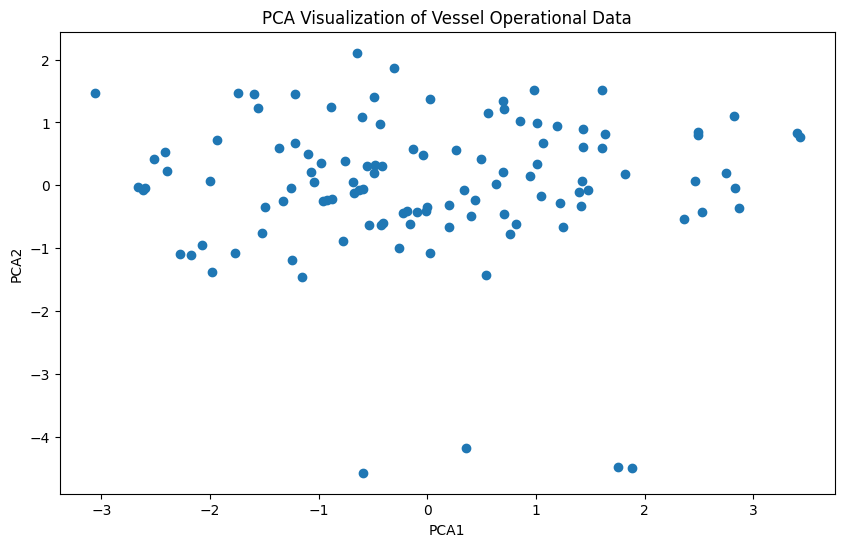

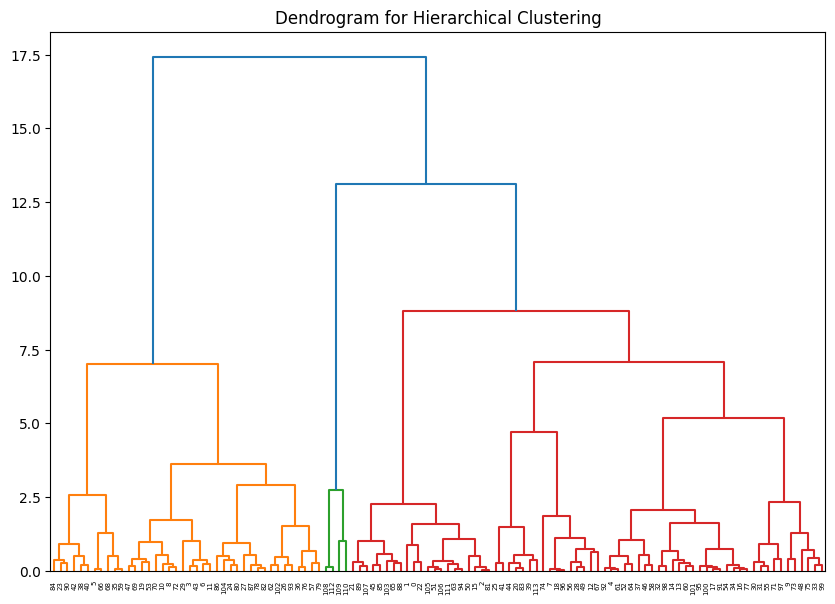

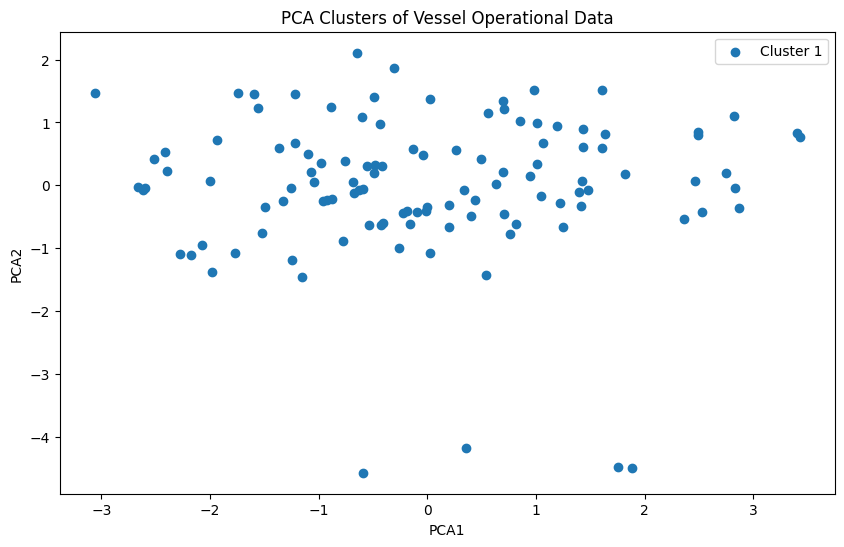

In [51]:
start_date = '2024-01-01'
end_date = '2024-12-31'
no_of_profiles = 1


# For SAIL data
sail_or_port_data = 'PORT'
cluster_data_port_pca, profile_data_port_pca,df_pca = find_data_clusters_and_profile(start_date, end_date, sail_or_port_data, no_of_profiles, data)


In [54]:
cluster_data_port_pca.to_excel("Port_Cluster.xlsx", index = False)

In [56]:
cluster_data_sail_pca.to_excel("Sail_Cluster.xlsx", index = False)